# Analysis & visualisation of microcensus data
Felix Zaussinger | 12.10.2022

**Core Analysis Goal(s)**
1. Compare different version of ISCO shares
2. Create plots
3.

**Key Insight(s)**
1.
2.
3.

In [42]:
import os
import sys
import logging
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import stats

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

from src import utils, plotting_utils, stats_utils
import mapping_career_causeways

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload

# OPTIONAL: always reload modules so that as you change code in src, it gets loaded
%autoreload 2

# Settings
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

sns.set_context("paper")
# sns.set(rc={'figure.figsize': (16, 9.)})
sns.set_style("ticks")

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 120)
pd.options.display.float_format = "{:,.2f}".format

logging.basicConfig(level=logging.INFO, stream=sys.stdout)

# load paths
useful_paths = utils.UsefulPaths()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### Read data

File paths

In [4]:
base_dir_sl = os.path.join(
    useful_paths.project_dir,
    "rcode",
    "D_Ergebnisse",
    "_OUTPUT_FINAL_GEPRUEFT_V2",
    "short_list_Teil1 V2",
    "geprüft",
)
base_dir_slt = os.path.join(
    useful_paths.project_dir,
    "rcode",
    "D_Ergebnisse",
    "_OUTPUT_FINAL_GEPRUEFT_V2",
    "short_list_tobi_Teil1 V2",
    "geprüft",
)

ISCO gbn shares

In [14]:
df_shares_isco_unwtd = pd.read_csv(
    os.path.join(
        useful_paths.data_processed, "esco", "final_gbn_shares_by_isco3d_unweighted.csv"
    ),
    index_col=0,
)
df_shares_isco3d_de = pd.read_csv(
    os.path.join(base_dir_sl, "weighted_occ_shares_ISCO3D_bearbeitet.csv")
)
df_shares_isco3d_de
# df_shares_isco_unwtd

,EF541UG1,n_obs,EF952_sum,share_green_wtd,share_green_unwtd,share_brown_wtd,share_brown_unwtd,share_neutral_wtd,share_neutral_unwtd,share_green_cat_abs_wtd,share_green_cat_abs_unwtd,share_brown_cat_abs_wtd,share_brown_cat_abs_unwtd,share_neutral_cat_abs_wtd,share_neutral_cat_abs_unwtd,share_green_cat_rel_wtd,share_green_cat_rel_unwtd,share_brown_cat_rel_wtd,share_brown_cat_rel_unwtd,share_neutral_cat_rel_wtd,share_neutral_cat_rel_unwtd
0,11,105.00,"12,347.16",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
1,21,72.00,"9,550.96",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
2,31,"1,263.00","168,173.18",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
3,111,383.00,"40,370.03",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
4,112,"6,730.00","734,645.32",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118,932,"3,351.00","383,081.00",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
119,933,"6,395.00","742,086.44",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
120,941,"3,264.00","385,568.92",0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00
121,961,510.00,"57,909.30",0.67,0.67,0.00,0.00,0.33,0.33,1.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,0.00


Combine

In [24]:
df_isco3d_merged_sl = pd.merge(
    df_shares_isco_unwtd,
    df_shares_isco3d_de,
    left_on="isco_code",
    right_on="EF541UG1",
    suffixes=("", "_sl"),
)

green_cols = df_isco3d_merged_sl.columns.str.contains("green")
brown_cols = df_isco3d_merged_sl.columns.str.contains("brown")

##### Correlations

In [30]:
import pingouin as pg
from sklearn.metrics import mean_squared_error
from src.stats_utils import rmse

df_isco3d_merged_sl.loc[:, green_cols].rcorr()

,share_green,share_green_wtd,share_green_unwtd,share_green_cat_abs_wtd,share_green_cat_abs_unwtd,share_green_cat_rel_wtd,share_green_cat_rel_unwtd
share_green,-,***,***,***,***,***,***
share_green_wtd,0.465,-,***,***,***,***,***
share_green_unwtd,0.464,1.0,-,***,***,***,***
share_green_cat_abs_wtd,0.438,0.99,0.99,-,***,***,***
share_green_cat_abs_unwtd,0.436,0.99,0.99,1.0,-,***,***
share_green_cat_rel_wtd,0.452,0.904,0.903,0.856,0.855,-,***
share_green_cat_rel_unwtd,0.451,0.904,0.903,0.856,0.855,1.0,-


<AxesSubplot:xlabel='share_green', ylabel='share_green_wtd'>

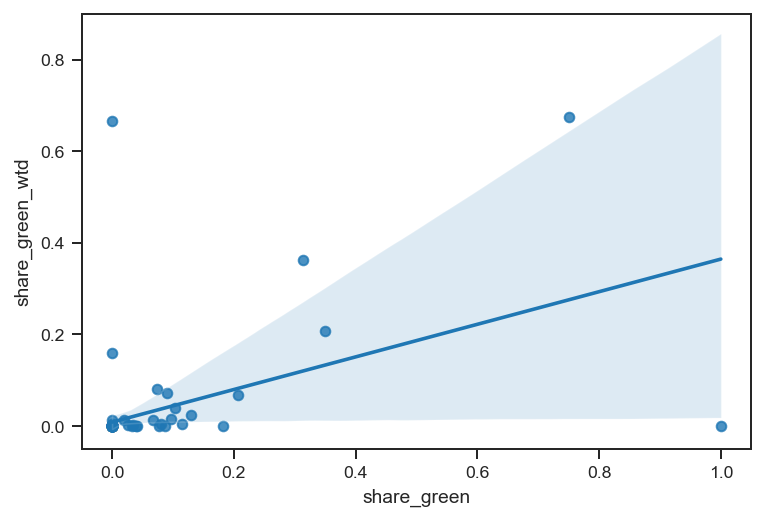

In [49]:
sns.regplot(data=df_isco3d_merged_sl, x="share_green", y="share_green_wtd")

<AxesSubplot:xlabel='share_green_unwtd', ylabel='share_green_wtd'>

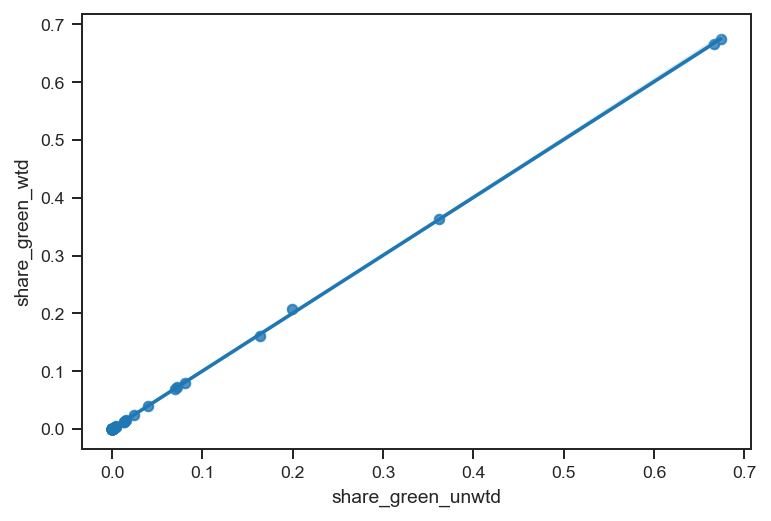

In [53]:
sns.regplot(data=df_isco3d_merged_sl, x="share_green_unwtd", y="share_green_wtd")

In [26]:
df_isco3d_merged_sl.loc[:, brown_cols].rcorr()

,share_brown_sl,share_brown_slt,share_brown_wtd,share_brown_unwtd,share_brown_cat_abs_wtd,share_brown_cat_abs_unwtd,share_brown_cat_rel_wtd,share_brown_cat_rel_unwtd
share_brown_sl,-,***,***,***,***,***,***,***
share_brown_slt,0.654,-,***,***,***,***,***,***
share_brown_wtd,0.961,0.609,-,***,***,***,***,***
share_brown_unwtd,0.962,0.609,1.0,-,***,***,***,***
share_brown_cat_abs_wtd,0.921,0.502,0.961,0.961,-,***,***,***
share_brown_cat_abs_unwtd,0.921,0.501,0.96,0.961,1.0,-,***,***
share_brown_cat_rel_wtd,0.879,0.563,0.878,0.878,0.777,0.777,-,***
share_brown_cat_rel_unwtd,0.878,0.562,0.877,0.877,0.776,0.777,1.0,-


<AxesSubplot:xlabel='share_brown_sl', ylabel='share_brown_wtd'>

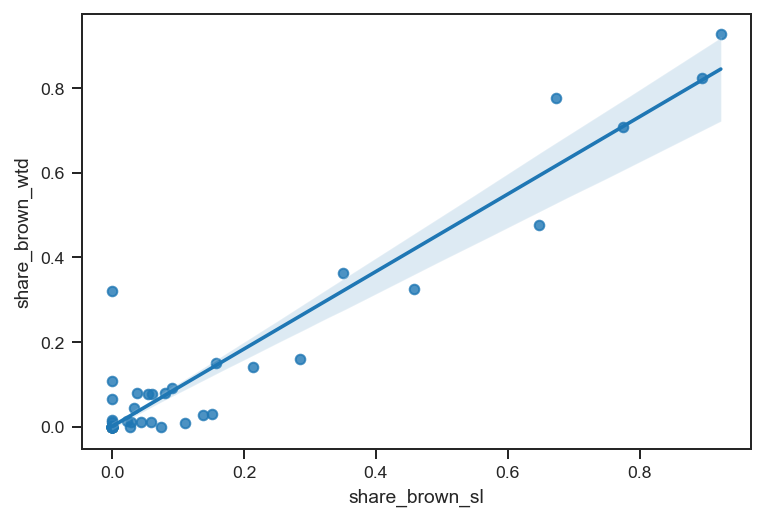

In [51]:
sns.regplot(data=df_isco3d_merged_sl, x="share_brown_sl", y="share_brown_wtd")

<AxesSubplot:xlabel='share_brown_unwtd', ylabel='share_brown_wtd'>

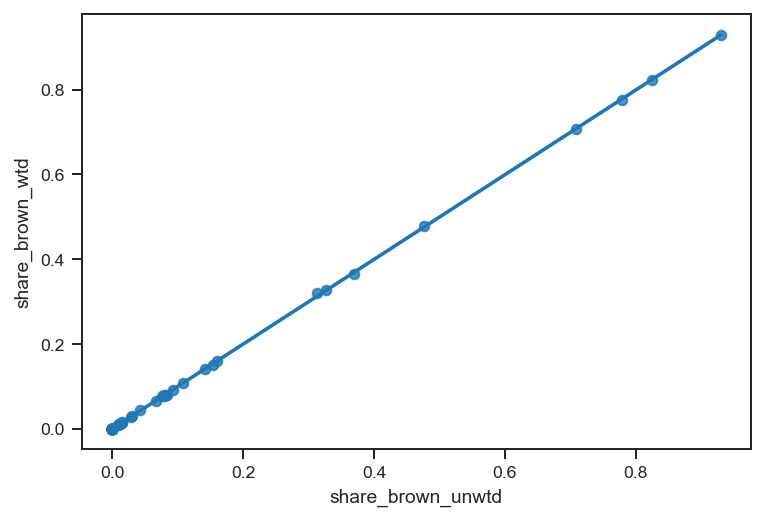

In [52]:
sns.regplot(data=df_isco3d_merged_sl, x="share_brown_unwtd", y="share_brown_wtd")

##### Deviations

Green

In [37]:
rmse(df_isco3d_merged_sl.share_green, df_isco3d_merged_sl.share_green_wtd)

0.012405068751851562

In [39]:
rmse(df_isco3d_merged_sl.share_green_wtd, df_isco3d_merged_sl.share_green_unwtd)

3.568400833333326e-05

Brown

In [38]:
rmse(df_isco3d_merged_sl.share_brown_sl, df_isco3d_merged_sl.share_brown_wtd)

0.003738058767458243

In [40]:
rmse(df_isco3d_merged_sl.share_brown_wtd, df_isco3d_merged_sl.share_brown_unwtd)

0.00013066256666666607